In [2]:
import pandas as pd
import matplotlib.pyplot as plt
df= pd.read_csv("../data/casen_limpio.csv")
df.head()


,genero,edad,region,nivel_educacion,sector_economico,situacion_laboral,ingreso_mensual,ocupado
0,Hombre,15,Metropolitana,Básica,NaN,Inactivo,NaN,False
1,Mujer,60,Valparaíso,Técnica,NaN,Inactivo,NaN,False
2,Hombre,60,Arica y Parinacota,Básica,Industria,Ocupado,466000.0,True
3,Hombre,34,Coquimbo,Universitaria,Comercio,Ocupado,611000.0,True
4,Mujer,50,Ñuble,Universitaria,NaN,Inactivo,NaN,False


In [3]:
tasa_ocupacion = df.groupby("genero")["ocupado"].mean() * 100
print(tasa_ocupacion.round(1))

genero
Hombre    71.5
Mujer     49.6
Name: ocupado, dtype: float64


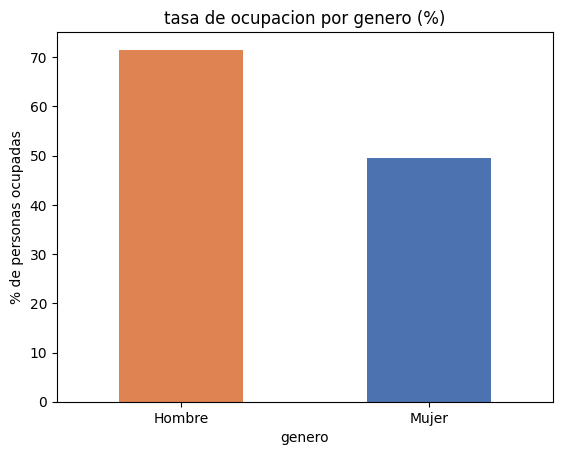

In [5]:
tasa_ocupacion.plot(kind="bar", color=["#dd8452","#4c72b0"], title="tasa de ocupacion por genero (%)")
plt.ylabel("% de personas ocupadas")
plt.xticks(rotation=0)
plt.show()

In [6]:
ocupados = df[df["ocupado"] == True]
ingreso_por_genero = ocupados.groupby("genero")["ingreso_mensual"].median()
print(ingreso_por_genero)

genero
Hombre    658000.0
Mujer     535000.0
Name: ingreso_mensual, dtype: float64


In [7]:
brecha = (ingreso_por_genero["Hombre"] - ingreso_por_genero["Mujer"]) / ingreso_por_genero["Hombre"] * 100
print(f"Brecha salarial: {brecha:.1f}%")

Brecha salarial: 18.7%


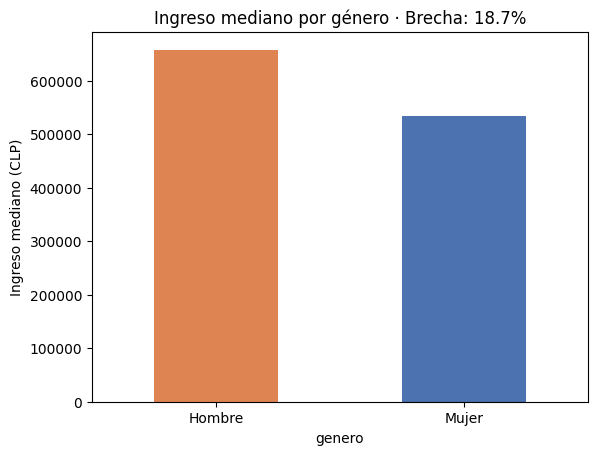

In [8]:
ingreso_por_genero.plot(kind="bar", color=["#DD8452", "#4C72B0"], title=f"Ingreso mediano por género · Brecha: {brecha:.1f}%")
plt.ylabel("Ingreso mediano (CLP)")
plt.xticks(rotation=0)
plt.show()

In [9]:
ingreso_por_edu = ocupados.groupby(["nivel_educacion", "genero"])["ingreso_mensual"].median().unstack()
print(ingreso_por_edu.round(0))

genero              Hombre      Mujer
nivel_educacion                      
Básica            413000.0   340000.0
Media             573000.0   483000.0
Postgrado        1552500.0  1206000.0
Técnica           751000.0   555500.0
Universitaria    1063000.0   868000.0


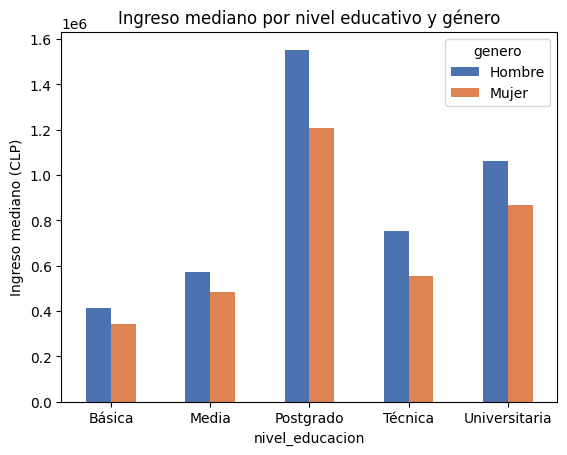

In [10]:
ingreso_por_edu.plot(kind="bar", color=["#4C72B0", "#DD8452"], title="Ingreso mediano por nivel educativo y género")
plt.ylabel("Ingreso mediano (CLP)")
plt.xticks(rotation=0)
plt.show()

In [11]:
sector_genero = ocupados.groupby(["sector_economico", "genero"]).size().unstack()
print(sector_genero)

genero                 Hombre  Mujer
sector_economico                    
Agricultura               409    141
Comercio                  609    555
Construcción              572     39
Educación y salud         577    718
Industria                 485    141
Minería                   216      7
Servicio doméstico         29    628
Servicios financieros     227    243
Transporte                357     73


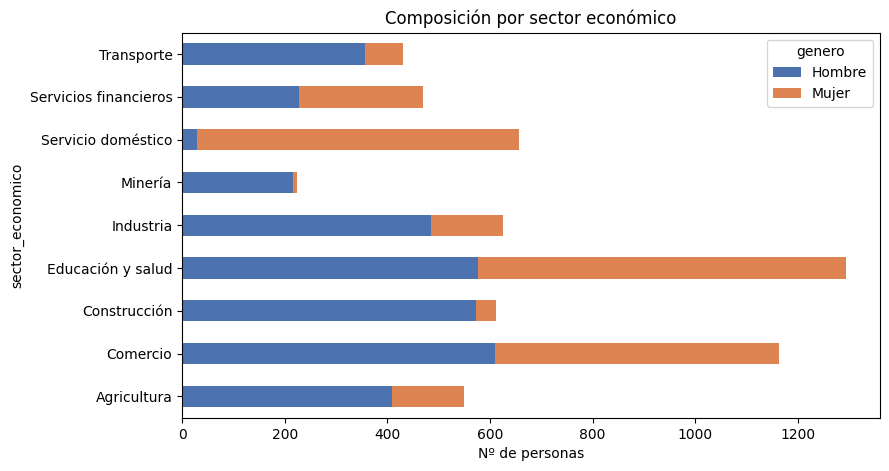

In [12]:
sector_genero.plot(kind="barh", stacked=True, color=["#4C72B0", "#DD8452"], title="Composición por sector económico", figsize=(9, 5))
plt.xlabel("Nº de personas")
plt.show()

In [13]:
ingreso_region = ocupados.groupby(["region", "genero"])["ingreso_mensual"].median().unstack()
ingreso_region["brecha_%"] = (ingreso_region["Hombre"] - ingreso_region["Mujer"]) / ingreso_region["Hombre"] * 100
ingreso_region = ingreso_region.sort_values("brecha_%")
print(ingreso_region.round(1))

genero                Hombre     Mujer  brecha_%
region                                          
Aysén               557000.0  846000.0     -51.9
Maule               535000.0  477000.0      10.8
Ñuble               605500.0  515000.0      14.9
Metropolitana       740000.0  625500.0      15.5
Coquimbo            567000.0  472000.0      16.8
Tarapacá            642000.0  532000.0      17.1
Magallanes          708000.0  582000.0      17.8
Valparaíso          625500.0  509000.0      18.6
O'Higgins           604000.0  484000.0      19.9
Biobío              558000.0  434500.0      22.1
Los Lagos           615500.0  472500.0      23.2
Atacama             723000.0  520000.0      28.1
Araucanía           533000.0  383000.0      28.1
Antofagasta         820000.0  566000.0      31.0
Los Ríos            674500.0  432000.0      36.0
Arica y Parinacota  686000.0  437000.0      36.3


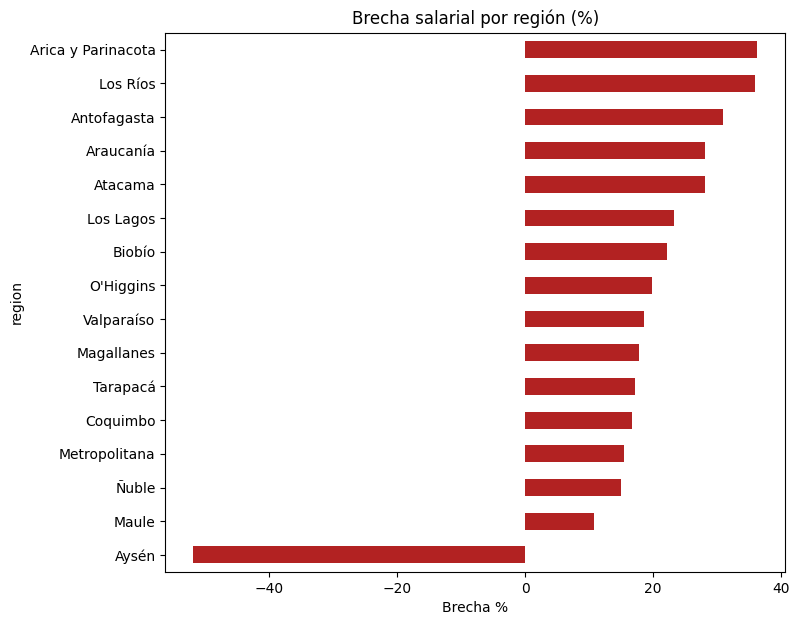

In [14]:
ingreso_region["brecha_%"].plot(kind="barh", color="#B22222", title="Brecha salarial por región (%)", figsize=(8, 7))
plt.xlabel("Brecha %")
plt.show()